In [2]:
import scanpy as sc
import anndata as ad
import scanpy.external as sce

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import scvi
import scipy.sparse as sp

from rich import print
import warnings
warnings.filterwarnings("ignore")
import os

outdir = "/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007"
os.makedirs(outdir, exist_ok=True)
sc.settings.figdir = "/scratch/user/s4575250/BIOX7018_thesis/figures/PICA/03_abundance_change"

In [3]:
# load annotations
adata = sc.read_h5ad("/scratch/user/s4575250/BIOX7018_thesis/data/Batch001-Batch007_raw_03_fine_annot.h5ad", backed="r")

adata.obs['pica_cell_type_complete_01_gdT_corrected'].unique()
adata.obs['pica_cell_type_complete_01_gdT_corrected'].value_counts()

pica_cell_type_complete_01_gdT_corrected
CD4 naive/Tcm                 407516
CD8 naive/Tcm                 175694
CD56_dim CD16+ NK             171221
gdT                           136632
CD4 Tem                        96510
Naive B cell                   74528
Classical monocyte             51309
CD8 Tem                        50185
Tfh                            45002
CD8 GZMK+ naive/Tcm            39689
Treg                           39431
Switched memory B cell         39115
MAIT                           33604
Transitional B cell            20038
CX3CR1_high ncMonocyte         16593
ILC1                           16331
CD56_dim CD16+ KLRC2+ NK       15081
Intermediate monocyte          10877
CD4 cytoT                       8027
Platelet                        7029
Atypical memory B cell          5734
cDC2                            5434
pDC                             4415
Proliferating lymphocyte        2683
iILC2                           2400
DP T                            23

In [3]:
adata.obs["pica_id"].unique()
adata.obs['pica_id'].value_counts().sort_index()

pica_id
PICA0001     3992
PICA0002     3367
PICA0003     3357
PICA0004     3554
PICA0005     4943
            ...  
PICA0164    12172
PICA0166    12216
PICA0168    12590
PICA0169    12506
PICA0173    13800
Name: count, Length: 128, dtype: int64

In [4]:
print(adata)

AnnData object with n_obs × n_vars = 1485141 × 38606 backed at 
'/scratch/user/s4575250/BIOX7018_thesis/data/Batch001-Batch007_raw_03_fine_annot.h5ad'
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 
'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 
'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 
'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 
'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 
'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 
'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 
'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 
'status_manual_01_pica', 'Record ID', 'Sex', 'Age (years)', 'Age'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'

### load metadata

In [5]:
meta_raw = pd.read_csv("/scratch/user/s4575250/BIOX7018_thesis/data/PICA-PICAReportOverall_DATA_LABELS_2025-07-25_1224.csv")

In [6]:
# convert Record ID -> PICA format (PICA0001)
meta = meta_raw.copy()
meta["Record ID"] = meta["Record ID"].astype(int)

meta["pica_id"] = meta["Record ID"].apply(lambda x: f"PICA{x:04d}")
meta.set_index("pica_id", inplace=True)

print(meta["Record ID"])

pica_id
PICA0001      1
PICA0002      2
PICA0003      3
PICA0004      4
PICA0005      5
           ... 
PICA0269    269
PICA0270    270
PICA0271    271
PICA0272    272
PICA0273    273
Name: Record ID, Length: 273, dtype: int64

In [7]:
# restrict meta to only those in adata
adata_picas = adata.obs["pica_id"].unique()
meta_sub = meta.loc[meta.index.isin(adata_picas)].copy()

print("Metadata before restricting:", meta.shape[0], "rows")
print("Metadata after restricting:", meta_sub.shape[0], "rows")

Metadata before restricting: 273 rows

Metadata after restricting: 128 rows

In [8]:
# mapping pica id in metadata to pica id in adata
adata.obs["pica_id"] = adata.obs["pica_id"].astype(str)
meta_sub.index = meta_sub.index.astype(str)

for col in meta_sub.columns:
    # build a mapping pica_id -> value
    mapping = meta_sub[col]
    adata.obs[col] = adata.obs["pica_id"].map(mapping)

adata.obs[[ "pica_id", "Record ID" ]].head()  
print("n_obs:", adata.n_obs)
print("obs rows:", adata.obs.shape[0])

n_obs: 1485141

obs rows: 1485141

In [9]:
print(adata.obs.columns)


Index(['status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch',
       'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts',
       'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'total_counts_mt',
       'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo',
       'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb',
       'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type',
       'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type',
       'pica_cell_type_01_myeloid', 'pica_cell_type_02_b',
       'pica_cell_type_03_nk_t', 'pica_cell_type_complete',
       'pica_broad_cell_type_complete',
       'pica_broad_cell_type_complete_01_gdT_corrected',
       'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica',
       'Record ID', 'Sex', 'Age (years)', 'Age', 'Event Name',
       'Was baseline blood sample collected?', 'IFC ID', 'Child's sex',
       'Age in years at the time of collection',
       'Age in months at the time of collection',
       '1) Does your child have any significant health issue or condition?',
       'Date and time of blood collection',
       '4) Does your child have any allergies diagnosed by a medical practitioner?',
       '5) Has your child shown any allergic symptoms within the last 2 months?',
       '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two 
weeks)?',
       '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and 
autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)',
       '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and 
autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)',
       '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and 
autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))',
       'My family member has a history of (specify family member)',
       'My child has a history of:  (Specify diagnosis date)',
       '8) Has your child ever been breastfed?',
       '9) What is your child's ethnicity? (choice=White Australian)',
       '9) What is your child's ethnicity? (choice=Australian Aboriginal)',
       '9) What is your child's ethnicity? (choice=Australian South Sea Islander)',
       '9) What is your child's ethnicity? (choice=Torres Strait Islander)',
       '9) What is your child's ethnicity? (choice=Māori)',
       '9) What is your child's ethnicity? (choice=New Zealander)',
       '9) What is your child's ethnicity? (choice=Pacific Islander)',
       '9) What is your child's ethnicity? (choice=North-West European)',
       '9) What is your child's ethnicity? (choice=Southern and Eastern European)',
       '9) What is your child's ethnicity? (choice=North African and Middle Eastern)',
       '9) What is your child's ethnicity? (choice=South-East Asian)',
       '9) What is your child's ethnicity? (choice=North-East Asian)',
       '9) What is your child's ethnicity? (choice=Southern and Central Asian)',
       '9) What is your child's ethnicity? (choice=Latin American and Caribbean)',
       '9) What is your child's ethnicity? (choice=Sub-Saharan African)',
       '9) What is your child's ethnicity? (choice=Decline to answer)',
       '9) What is your child's ethnicity? (choice=Other, please specify:)',
       'Specify ethnicity'],
      dtype='object')

In [10]:
meta_summary = (
    adata.obs[["pica_id", "Child's sex", "Age in years at the time of collection"]]
    .drop_duplicates()
    .sort_values("pica_id")
)
print(meta_summary)

pica_id Child's sex  \
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...  PICA0001        Male   
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...  PICA0002        Male   
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...  PICA0003        Male   
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...  PICA0004        Male   
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...  PICA0005        Male   
...                                                      ...         ...   
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...  PICA0164        Male   
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...  PICA0166        Male   
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...  PICA0168        Male   
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...  PICA0169        Male   
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...  PICA0173        Male   

                                                    Age in years at the time of collection  
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...                                    2.09  
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...                                   15.09  
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...                                    0.83  
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...                                    3.46  
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...                                    9.30  
...                                                                                    ...  
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...                                    2.15  
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...                                    0.62  
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...                                   16.20  
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...                                    2.72  
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...                                   15.31  

[128 rows x 3 columns]

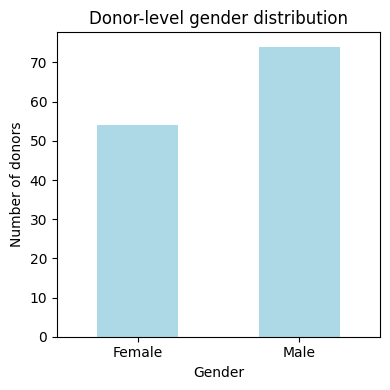

In [11]:
gender_meta_df = adata.obs[["pica_id", "Child's sex"]].drop_duplicates()

gender_meta_df["Child's sex"].value_counts().sort_index().plot(
    kind="bar", color="lightblue", figsize=(4,4)
)
plt.title("Donor-level gender distribution")
plt.xlabel("Gender")
plt.ylabel("Number of donors")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

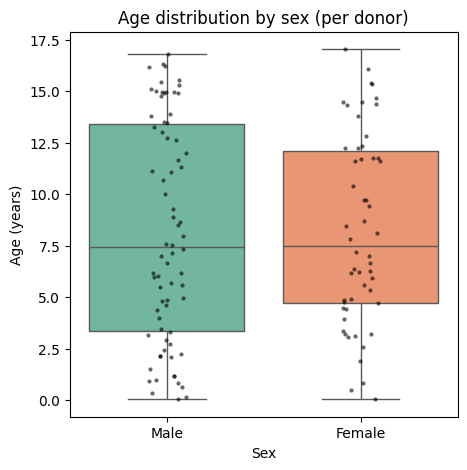

In [12]:
meta_df = adata.obs[['pica_id', "Child's sex", "Age in years at the time of collection"]].drop_duplicates()

plt.figure(figsize=(5,5))
sns.boxplot(data=meta_df, x="Child's sex", y="Age in years at the time of collection", palette="Set2")
sns.stripplot(data=meta_df, x="Child's sex", y="Age in years at the time of collection", color="k", size=3, alpha=0.6)
plt.title("Age distribution by sex (per donor)")
plt.ylabel("Age (years)")
plt.xlabel("Sex")
plt.show()

In [13]:
adata.obs = adata.obs.applymap(
    lambda x: str(x) if not isinstance(x, (int, float, str)) else x
)

In [14]:
adata.write_h5ad("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_combined_annot_meta.h5ad", compression="gzip")

### clean up age

In [5]:
adata_age=sc.read_h5ad("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_combined_annot_meta.h5ad")

In [6]:
print(adata_age)

AnnData object with n_obs × n_vars = 1485141 × 38606
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 
'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 
'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 
'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 
'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 
'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 
'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 
'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 
'status_manual_01_pica', 'Record ID', 'Sex', 'Age (years)', 'Age', 'Event Name', 'Was baseline blood sample 
collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of 
collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood 
collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown
any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating
medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune 
disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) 
(choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies 
and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or 
your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, 
type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family 
member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) 
What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian 
Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's
ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your 
child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) 
What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern
and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is
your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)",
"9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? 
(choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What
is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please 
specify:)", 'Specify ethnicity'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'

In [7]:
adata_age.obs.groupby("pica_id")["Age in years at the time of collection"].unique()

pica_id
PICA0001     [2.09]
PICA0002    [15.09]
PICA0003     [0.83]
PICA0004     [3.46]
PICA0005      [9.3]
             ...   
PICA0164     [2.15]
PICA0166     [0.62]
PICA0168     [16.2]
PICA0169     [2.72]
PICA0173    [15.31]
Name: Age in years at the time of collection, Length: 128, dtype: object

In [8]:
adata_age.obs["Age_in_years_int"] = (
    adata_age.obs["Age in years at the time of collection"]
    .astype(float)
    .apply(np.floor)  
    .astype(int)
)

In [9]:
adata_age.obs.groupby("pica_id")["Age_in_years_int"].unique()

pica_id
PICA0001     [2]
PICA0002    [15]
PICA0003     [0]
PICA0004     [3]
PICA0005     [9]
            ... 
PICA0164     [2]
PICA0166     [0]
PICA0168    [16]
PICA0169     [2]
PICA0173    [15]
Name: Age_in_years_int, Length: 128, dtype: object

In [10]:
# Define bins and labels
bins = [0, 3, 6, 10, 14, 18]
labels = ["0–3", "4–6", "7–10", "11–14", "15–18"]

# Create new column for grouped ages
adata_age.obs["Age_group"] = pd.cut(
    adata_age.obs["Age_in_years_int"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)

In [11]:
adata_age.obs["Age_in_years_int"].value_counts().sort_index()

Age_in_years_int
0     104303
1      49673
2      87995
3      94778
4     151808
5      80498
6     120162
7      92155
8      69967
9      43193
10     35359
11    121864
12     71899
13     91584
14    130672
15     68505
16     56628
17     14098
Name: count, dtype: int64

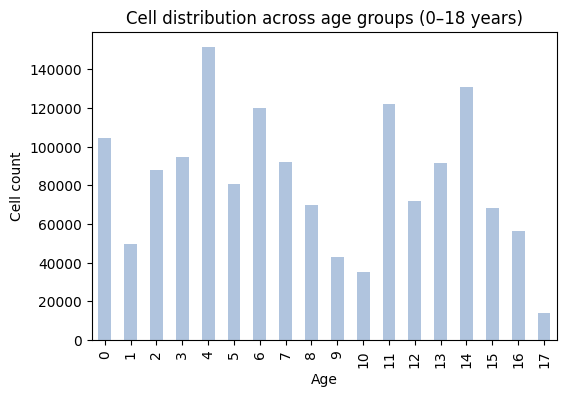

In [12]:
adata_age.obs["Age_in_years_int"].value_counts().sort_index().plot(
    kind="bar", figsize=(6,4), color="lightsteelblue"
)
plt.title("Cell distribution across age groups (0–18 years)")
plt.xlabel("Age")
plt.ylabel("Cell count")
plt.show()

In [13]:
adata_age.obs["Age_group"].value_counts().sort_index()

Age_group
0–3      336749
4–6      352468
7–10     240674
11–14    416019
15–18    139231
Name: count, dtype: int64

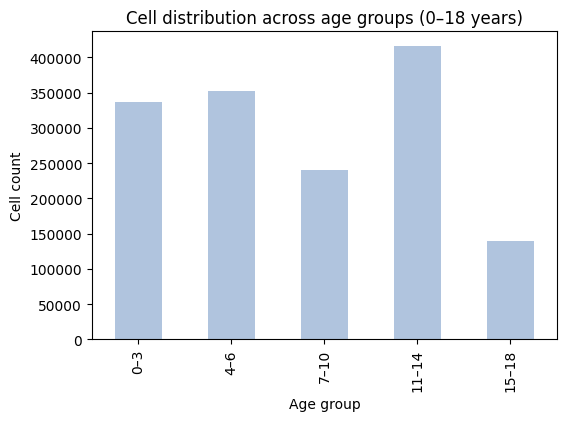

In [14]:
adata_age.obs["Age_group"].value_counts().sort_index().plot(
    kind="bar", figsize=(6,4), color="lightsteelblue"
)
plt.title("Cell distribution across age groups (0–18 years)")
plt.xlabel("Age group")
plt.ylabel("Cell count")
plt.show()

In [21]:
# create donor-level age group summary
age_meta_df = adata_age.obs[["pica_id", "Age_in_years_int"]].drop_duplicates()

age_order = list(range(0, 19))
age_counts = (
    age_meta_df["Age_in_years_int"]
    .value_counts()
    .reindex(age_order, fill_value=0)
)

age_counts

Age_in_years_int
0     10
1      4
2      8
3      9
4     12
5      7
6     10
7      8
8      6
9      4
10     3
11    10
12     6
13     7
14    11
15     7
16     5
17     1
18     0
Name: count, dtype: int64

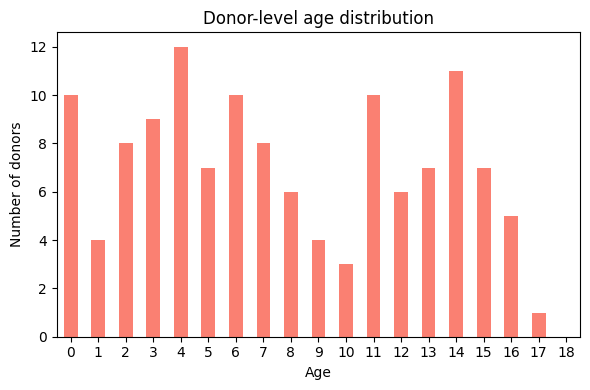

In [22]:
age_counts.plot(
    kind="bar",
    color="salmon",
    figsize=(6, 4)
)
plt.title("Donor-level age distribution")
plt.xlabel("Age")
plt.ylabel("Number of donors")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
# create donor-level age group summary
age_grp_meta_df = adata_age.obs[["pica_id", "Age_group"]].drop_duplicates()
age_grp_meta_df["Age_group"].value_counts().sort_index()

Age_group
0–3      31
4–6      29
7–10     21
11–14    34
15–18    13
Name: count, dtype: int64

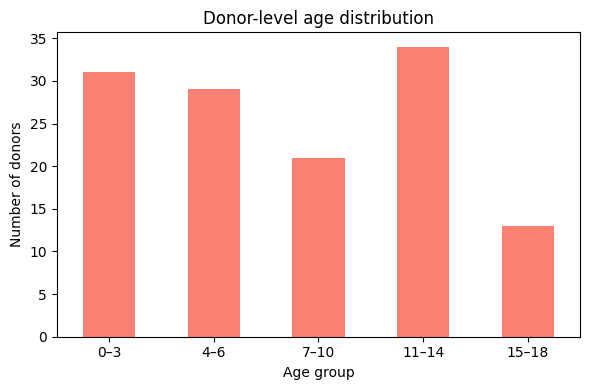

In [18]:
age_grp_meta_df["Age_group"].value_counts().sort_index().plot(
    kind="bar", color="salmon", figsize=(6,4)
)
plt.title("Donor-level age distribution")
plt.xlabel("Age group")
plt.ylabel("Number of donors")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [23]:
adata_age.write_h5ad("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_combined_annot_with_age.h5ad", compression="gzip")

### extract CD4 annotations

In [2]:
adata_subsets = sc.read_h5ad("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_combined_annot_with_age.h5ad",backed='r')

In [3]:
cd4_cells = [
    "CD4 naive/Tcm", "CD4 Tem", "Tfh", "Treg", "CD4 cytoT",
]

cd8_cells = [
    "CD8 naive/Tcm", "CD8 GZMK+ naive/Tcm", "CD8 Tem", 
]

other_t_cells = [
    "gdT", "MAIT", "DN T", "DP T", "NKT", 'Proliferating lymphocyte',
]

nk_cells = [
    "ILC1", "nILC2", "iILC2",
    "CD56_dim CD16+ NK", "CD56_dim CD16+ KLRC2+ NK", "CD56_bright CD16- NK",
]


In [4]:
adata_subsets.shape

(1485141, 38606)

In [5]:
adata_subsets.X.dtype

dtype('<f4')

In [6]:
obs = adata_subsets.obs.copy()

In [7]:
col = "pica_cell_type_complete_01_gdT_corrected"

obs["major_lineage"] = "Other"

# assign each group
obs.loc[obs[col].isin(cd4_cells), "major_lineage"] = "CD4"
obs.loc[obs[col].isin(cd8_cells), "major_lineage"] = "CD8"
obs.loc[obs[col].isin(nk_cells),  "major_lineage"] = "NK"
obs.loc[obs[col].isin(other_t_cells), "major_lineage"] = "Other_T"

In [8]:
print(obs["major_lineage"].head())

20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCAAAGAAAGCGT    CD4
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCAAAGAACGGCA     NK
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCAAAGACAATAG    CD4
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCAAAGACTTACG    CD4
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCAAAGATGGCGA     NK
Name: major_lineage, dtype: object

<Axes: xlabel='major_lineage'>

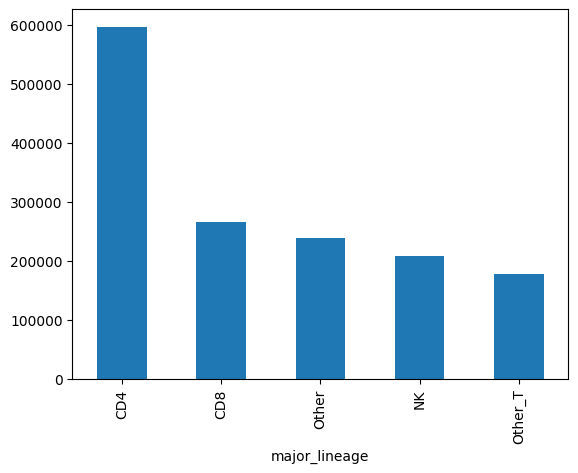

In [9]:
obs["major_lineage"].value_counts().plot(kind="bar")

In [10]:
(obs["major_lineage"].value_counts(normalize=True) * 100).round(2)

major_lineage
CD4        40.16
CD8        17.88
Other      16.04
NK         13.97
Other_T    11.95
Name: proportion, dtype: float64

In [11]:
pd.crosstab(obs["major_lineage"], obs["Age_group"])


Age_group,0–3,4–6,7–10,11–14,15–18
major_lineage,,,,,
CD4,151860,134748,91711,162356,55811
CD8,58370,64945,43721,72625,25907
NK,43157,52937,36738,55902,18724
Other,55549,53892,36759,69383,22623
Other_T,27813,45946,31745,55753,16166


In [12]:
pd.crosstab(obs["major_lineage"], obs["Age_group"], normalize="index").round(3)


Age_group,0–3,4–6,7–10,11–14,15–18
major_lineage,,,,,
CD4,0.255,0.226,0.154,0.272,0.094
CD8,0.220,0.245,0.165,0.273,0.098
NK,0.208,0.255,0.177,0.269,0.090
Other,0.233,0.226,0.154,0.291,0.095
Other_T,0.157,0.259,0.179,0.314,0.091


In [13]:
# CD4
cd4_mask = obs["major_lineage"] == "CD4"
cd4_mask.sum()

np.int64(596486)

In [14]:
cd4_idx = np.where(cd4_mask)[0]
len(cd4_idx)

596486

In [15]:
adata_cd4 = adata_subsets[cd4_idx, :].to_memory()
print(adata_cd4.shape) 

(596486, 38606)

In [16]:
print(adata_cd4)

AnnData object with n_obs × n_vars = 596486 × 38606
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 
'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 
'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 
'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 
'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 
'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 
'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 
'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 
'status_manual_01_pica', 'Record ID', 'Sex', 'Age (years)', 'Age', 'Event Name', 'Was baseline blood sample 
collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of 
collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood 
collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown
any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating
medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune 
disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) 
(choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies 
and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or 
your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, 
type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family 
member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) 
What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian 
Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's
ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your 
child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) 
What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern
and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is
your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)",
"9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? 
(choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What
is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please 
specify:)", 'Specify ethnicity', 'Age_in_years_int', 'Age_group'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'

In [17]:
adata_cd4.write_h5ad("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd4_combined_annot_with_age.h5ad",
    compression="gzip"
)

In [18]:
del adata_cd4

In [19]:
# CD8
cd8_mask = obs["major_lineage"] == "CD8"
cd8_mask.sum()

np.int64(265568)

In [20]:
cd8_idx = np.where(cd8_mask)[0]
len(cd8_idx)

265568

In [21]:
adata_cd8 = adata_subsets[cd8_idx, :].to_memory()
print(adata_cd8.shape) 

(265568, 38606)

In [22]:
print(adata_cd8)

AnnData object with n_obs × n_vars = 265568 × 38606
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 
'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 
'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 
'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 
'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 
'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 
'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 
'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 
'status_manual_01_pica', 'Record ID', 'Sex', 'Age (years)', 'Age', 'Event Name', 'Was baseline blood sample 
collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of 
collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood 
collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown
any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating
medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune 
disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) 
(choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies 
and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or 
your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, 
type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family 
member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) 
What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian 
Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's
ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your 
child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) 
What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern
and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is
your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)",
"9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? 
(choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What
is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please 
specify:)", 'Specify ethnicity', 'Age_in_years_int', 'Age_group'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'

In [23]:
adata_cd8.write_h5ad("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd8_combined_annot_with_age.h5ad",
    compression="gzip"
)

In [24]:
del adata_cd8

In [25]:
# NK
nk_mask = obs["major_lineage"] == "NK"
nk_mask.sum()

np.int64(207458)

In [26]:
nk_idx = np.where(nk_mask)[0]
len(nk_idx)

207458

In [27]:
adata_nk = adata_subsets[nk_idx, :].to_memory()
print(adata_nk.shape) 

(207458, 38606)

In [28]:
print(adata_nk)

AnnData object with n_obs × n_vars = 207458 × 38606
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 
'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 
'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 
'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 
'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 
'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 
'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 
'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 
'status_manual_01_pica', 'Record ID', 'Sex', 'Age (years)', 'Age', 'Event Name', 'Was baseline blood sample 
collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of 
collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood 
collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown
any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating
medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune 
disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) 
(choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies 
and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or 
your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, 
type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family 
member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) 
What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian 
Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's
ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your 
child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) 
What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern
and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is
your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)",
"9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? 
(choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What
is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please 
specify:)", 'Specify ethnicity', 'Age_in_years_int', 'Age_group'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'

In [29]:
adata_nk.write_h5ad("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_nk_combined_annot_with_age.h5ad",
    compression="gzip"
)

In [30]:
del adata_nk

#### run scvi for cd4

In [2]:
adata_scvi_cd4 =sc.read_h5ad("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd4_combined_annot_with_age.h5ad")


adata_scvi_cd4.obs['pica_cell_type_complete_01_gdT_corrected'].unique()
adata_scvi_cd4.obs['pica_cell_type_complete_01_gdT_corrected'].value_counts()

pica_cell_type_complete_01_gdT_corrected
CD4 naive/Tcm    407516
CD4 Tem           96510
Tfh               45002
Treg              39431
CD4 cytoT          8027
Name: count, dtype: int64

In [3]:
print(adata_scvi_cd4)

AnnData object with n_obs × n_vars = 596486 × 38606
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 
'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 
'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 
'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 
'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 
'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 
'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 
'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 
'status_manual_01_pica', 'Record ID', 'Sex', 'Age (years)', 'Age', 'Event Name', 'Was baseline blood sample 
collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of 
collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood 
collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown
any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating
medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune 
disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) 
(choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies 
and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or 
your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, 
type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family 
member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) 
What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian 
Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's
ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your 
child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) 
What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern
and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is
your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)",
"9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? 
(choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What
is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please 
specify:)", 'Specify ethnicity', 'Age_in_years_int', 'Age_group'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'

In [4]:
adata_scvi_cd4.layers["counts"] = adata_scvi_cd4.X.copy()


In [5]:
scvi.model.SCVI.setup_anndata(
    adata_scvi_cd4,
    layer="counts",    
    batch_key="pica_id" 
)

In [6]:
model_cd4 = scvi.model.SCVI(adata_scvi_cd4, n_layers=2, n_latent=30, gene_likelihood="nb")

In [7]:
model_cd4.train()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA A16') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/13 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=13` reached.


In [8]:
adata_scvi_cd4.obsm["X_scVI"] = model_cd4.get_latent_representation()

#  latent representation 
sc.pp.neighbors(adata_scvi_cd4, use_rep="X_scVI")
sc.tl.umap(adata_scvi_cd4)


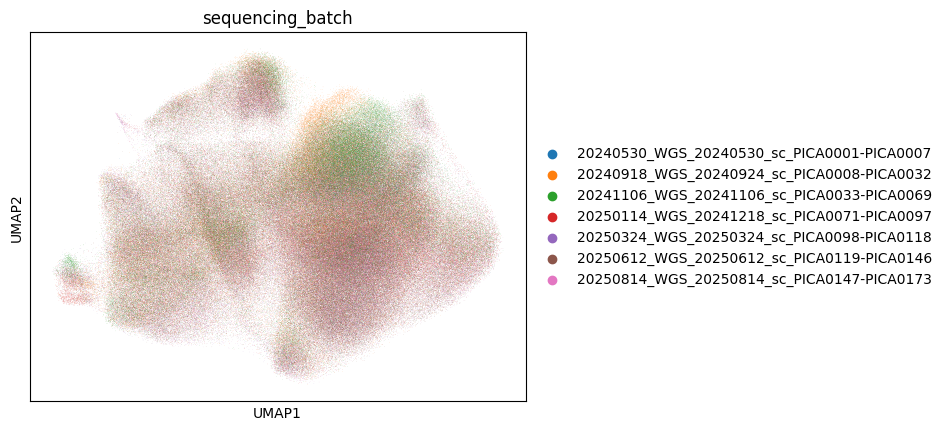

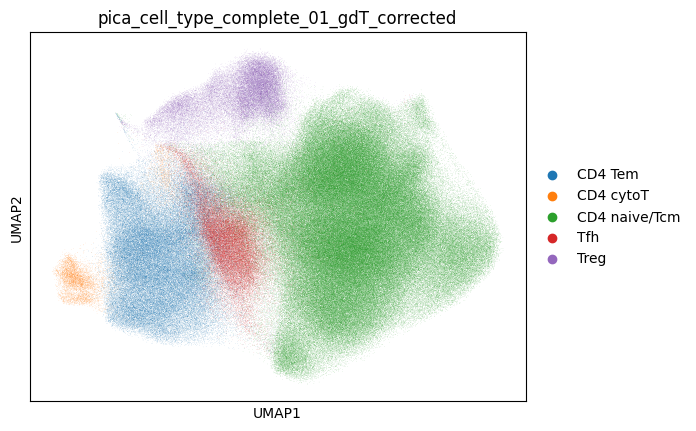

In [37]:

sc.pl.umap(adata_scvi_cd4, color="sequencing_batch")
sc.pl.umap(adata_scvi_cd4, color="pica_cell_type_complete_01_gdT_corrected")

In [10]:
print(adata_scvi_cd4)

AnnData object with n_obs × n_vars = 596486 × 38606
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 
'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 
'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 
'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 
'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 
'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 
'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 
'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 
'status_manual_01_pica', 'Record ID', 'Sex', 'Age (years)', 'Age', 'Event Name', 'Was baseline blood sample 
collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of 
collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood 
collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown
any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating
medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune 
disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) 
(choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies 
and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or 
your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, 
type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family 
member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) 
What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian 
Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's
ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your 
child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) 
What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern
and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is
your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)",
"9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? 
(choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What
is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please 
specify:)", 'Specify ethnicity', 'Age_in_years_int', 'Age_group', '_scvi_batch', '_scvi_labels'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
    uns: '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'umap', 'sequencing_batch_colors', 'cell_type_colors'
    obsm: 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [11]:
adata_scvi_cd4.write_h5ad("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd4_combined_annot_with_age_scvi.h5ad", compression="gzip")

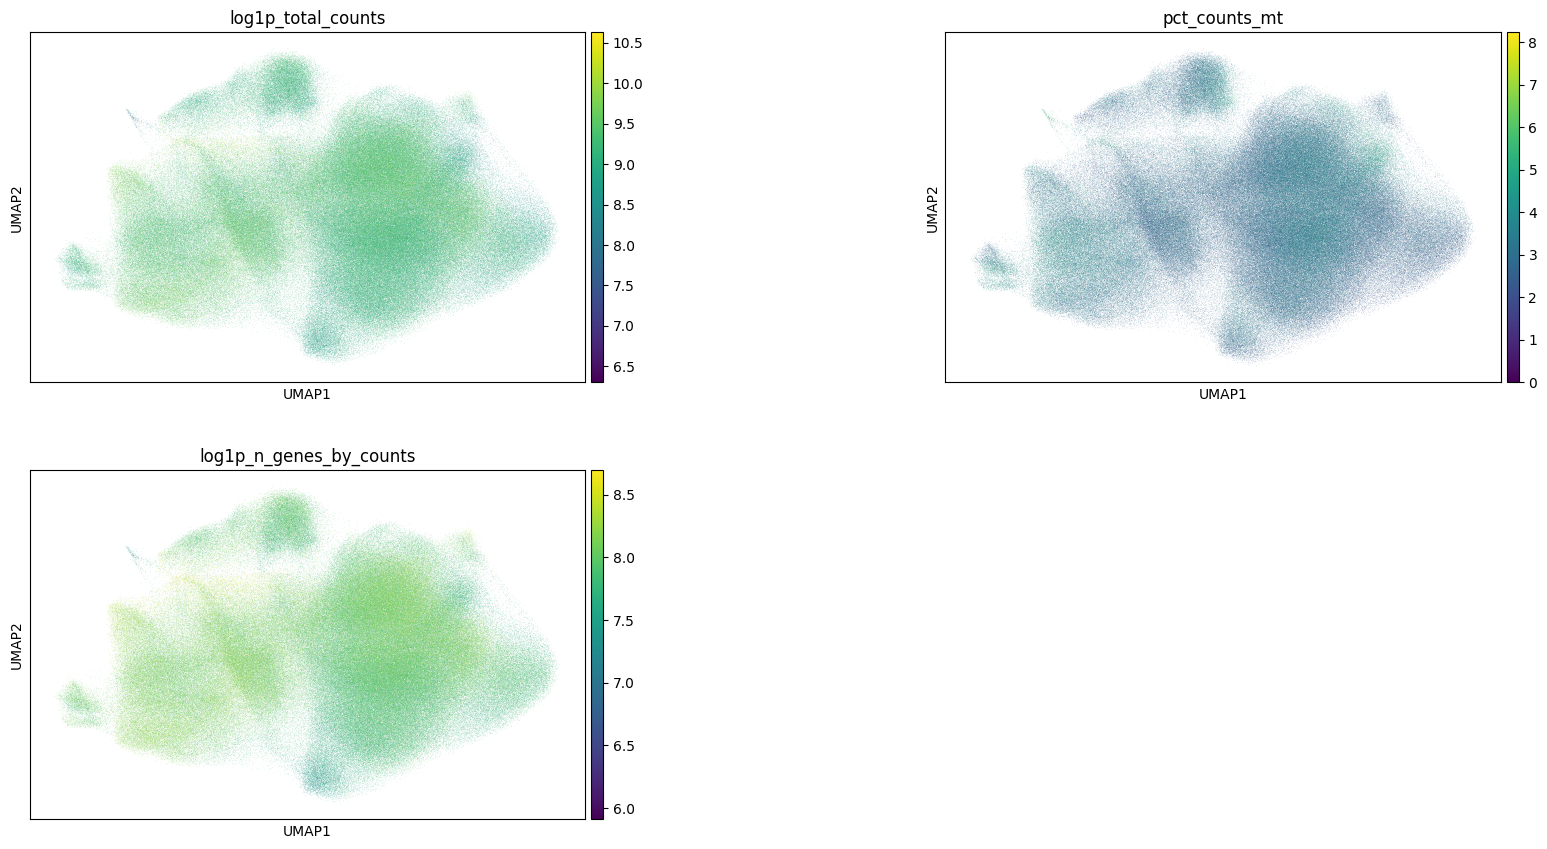

In [12]:
sc.pl.umap(
    adata_scvi_cd4,
    color=["log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"],
    wspace=0.5,
    ncols=2
)

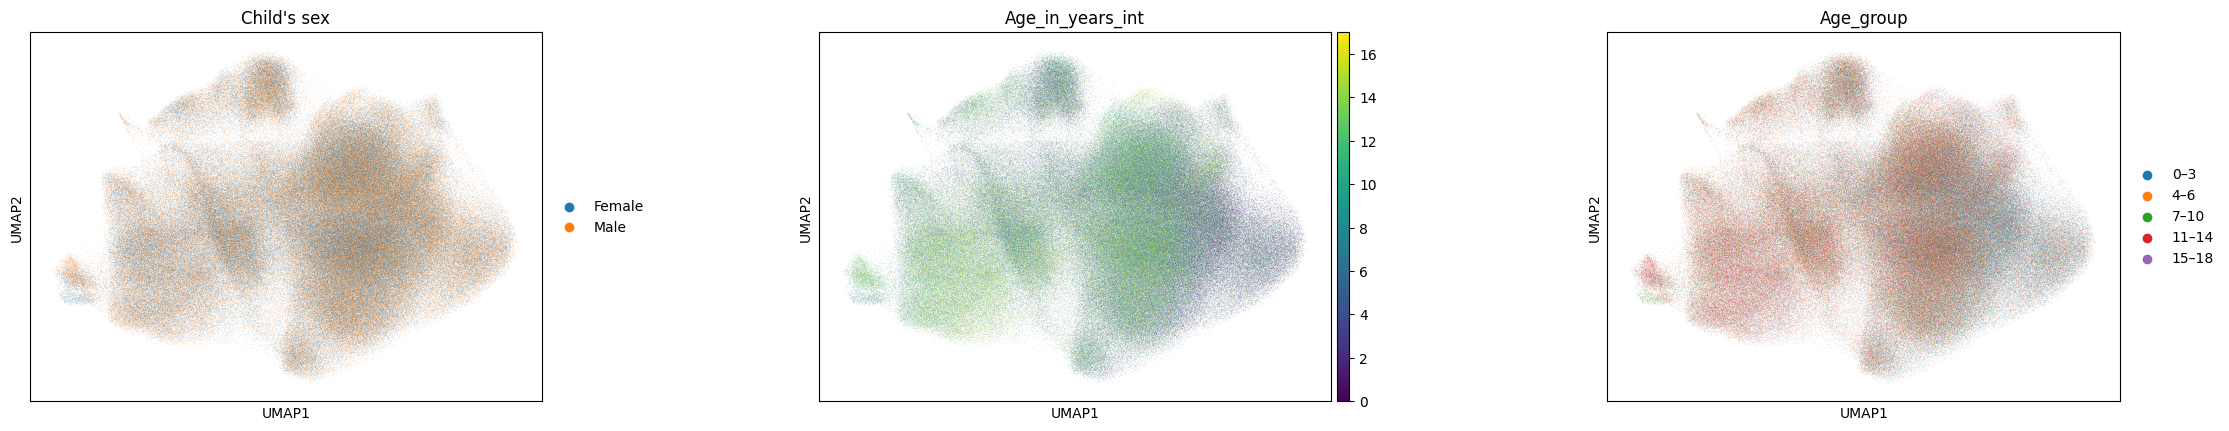

In [13]:
sc.pl.umap(adata_scvi_cd4, color=["Child's sex", "Age_in_years_int", "Age_group"], wspace=0.4)

#### convert to sce object

In [6]:
adata_cd4=sc.read_h5ad("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd4_combined_annot_with_age_scvi.h5ad")

AttributeError: 'dict' object has no attribute 'shape'

In [ ]:
import anndata2ri
import rpy2.robjects as robjects
from rpy2.robjects.conversion import localconverter

with localconverter(robjects.default_converter + anndata2ri.converter):
    sce = robjects.conversion.py2rpy(adata_scvi_cd4)

# Save the sce object in .rds file
robjects.globalenv["sce"] = sce
robjects.r("saveRDS(sce, file='{}')".format("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd4_combined_annot_with_age_scvi.sce.rds"))

ImportError: cannot import name 'conversion' from 'rpy2.robjects' (unknown location)

: 

#### run scvi for cd8

In [14]:
adata_scvi_cd8 =sc.read_h5ad("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd8_combined_annot_with_age.h5ad")


adata_scvi_cd8.obs['pica_cell_type_complete_01_gdT_corrected'].unique()
adata_scvi_cd8.obs['pica_cell_type_complete_01_gdT_corrected'].value_counts()

pica_cell_type_complete_01_gdT_corrected
CD8 naive/Tcm          175694
CD8 Tem                 50185
CD8 GZMK+ naive/Tcm     39689
Name: count, dtype: int64

In [15]:
adata_scvi_cd8.layers["counts"] = adata_scvi_cd8.X.copy()

In [16]:
scvi.model.SCVI.setup_anndata(adata_scvi_cd8, layer="counts", batch_key="pica_id")

In [17]:
model_cd8 = scvi.model.SCVI(adata_scvi_cd8, n_layers=2, n_latent=30, gene_likelihood="nb")

In [18]:
model_cd8.train()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/30 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.


In [19]:
adata_scvi_cd8.obsm["X_scVI"] = model_cd8.get_latent_representation()

#  latent representation 
sc.pp.neighbors(adata_scvi_cd8, use_rep="X_scVI")
sc.tl.umap(adata_scvi_cd8)

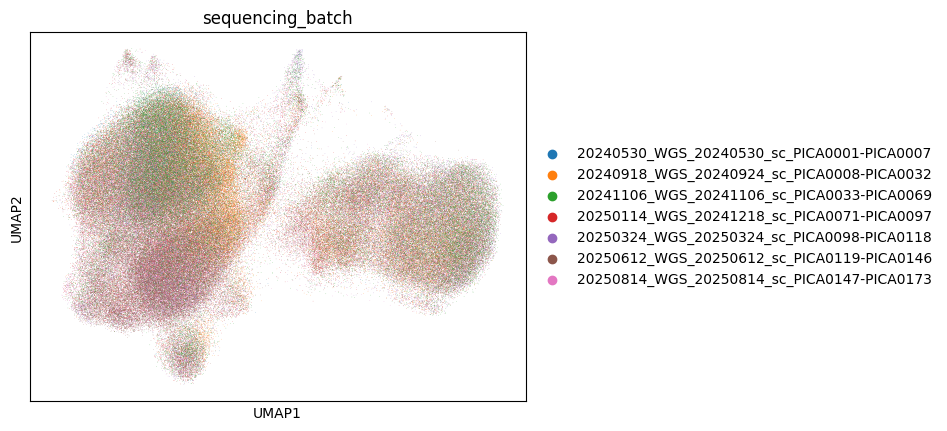

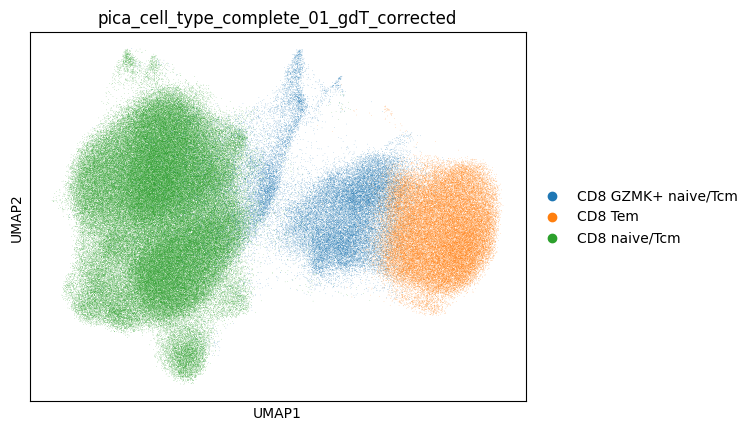

In [20]:

sc.pl.umap(adata_scvi_cd8, color="sequencing_batch")
sc.pl.umap(adata_scvi_cd8, color="pica_cell_type_complete_01_gdT_corrected")

In [21]:
print(adata_scvi_cd8)

AnnData object with n_obs × n_vars = 265568 × 38606
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 
'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 
'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 
'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 
'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 
'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 
'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 
'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 
'status_manual_01_pica', 'Record ID', 'Sex', 'Age (years)', 'Age', 'Event Name', 'Was baseline blood sample 
collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of 
collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood 
collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown
any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating
medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune 
disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) 
(choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies 
and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or 
your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, 
type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family 
member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) 
What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian 
Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's
ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your 
child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) 
What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern
and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is
your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)",
"9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? 
(choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What
is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please 
specify:)", 'Specify ethnicity', 'Age_in_years_int', 'Age_group', '_scvi_batch', '_scvi_labels'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
    uns: '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'umap', 'sequencing_batch_colors', 
'pica_cell_type_complete_01_gdT_corrected_colors'
    obsm: 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [22]:
adata_scvi_cd8.write_h5ad("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd8_combined_annot_with_age_scvi.h5ad", compression="gzip")

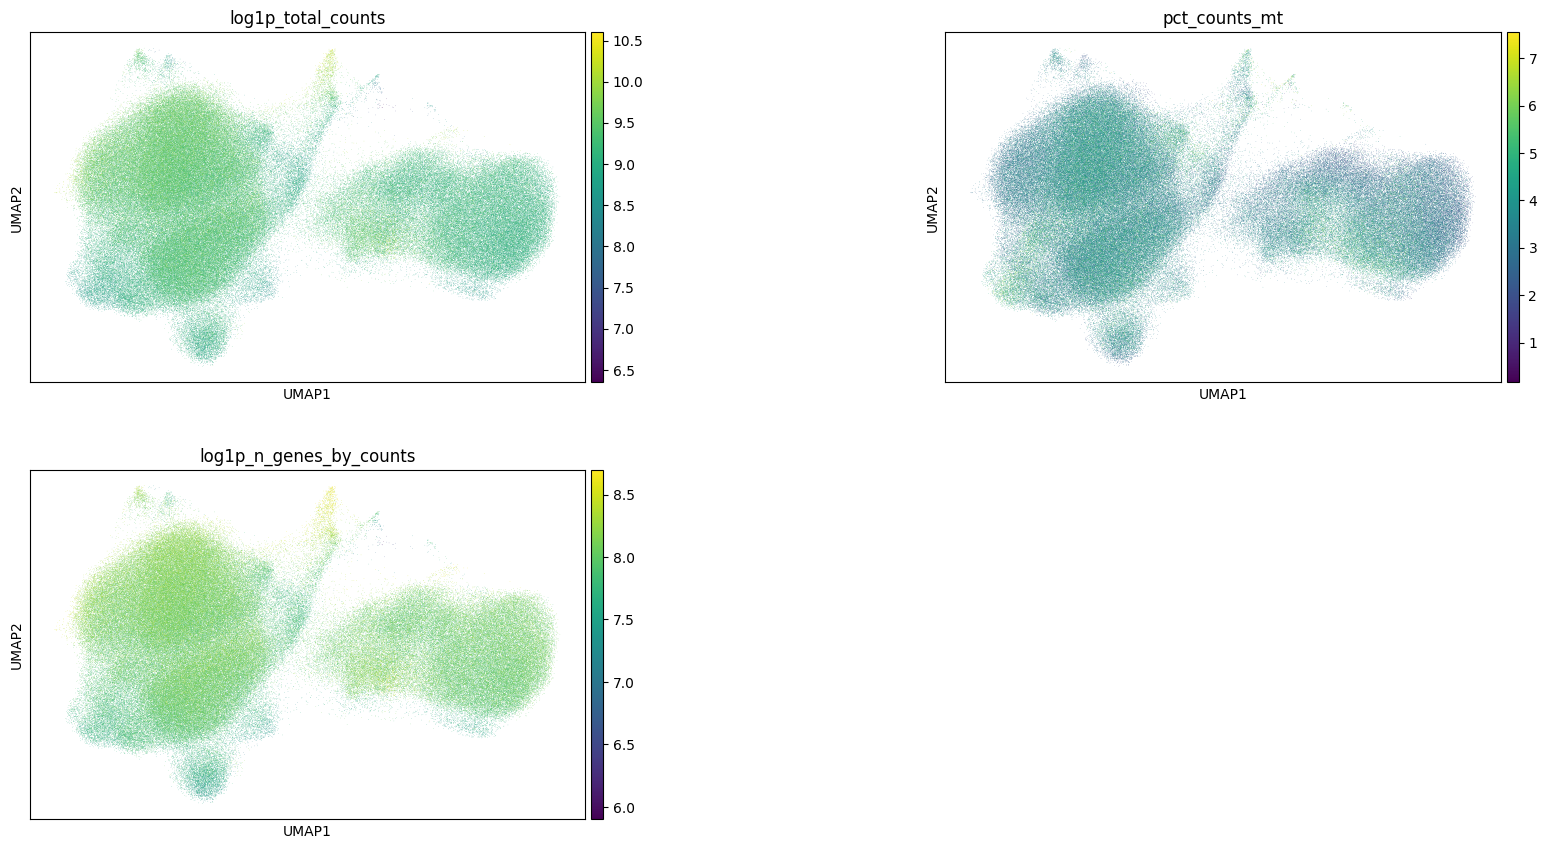

In [23]:
sc.pl.umap(
    adata_scvi_cd8,
    color=["log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"],
    wspace=0.5,
    ncols=2
)

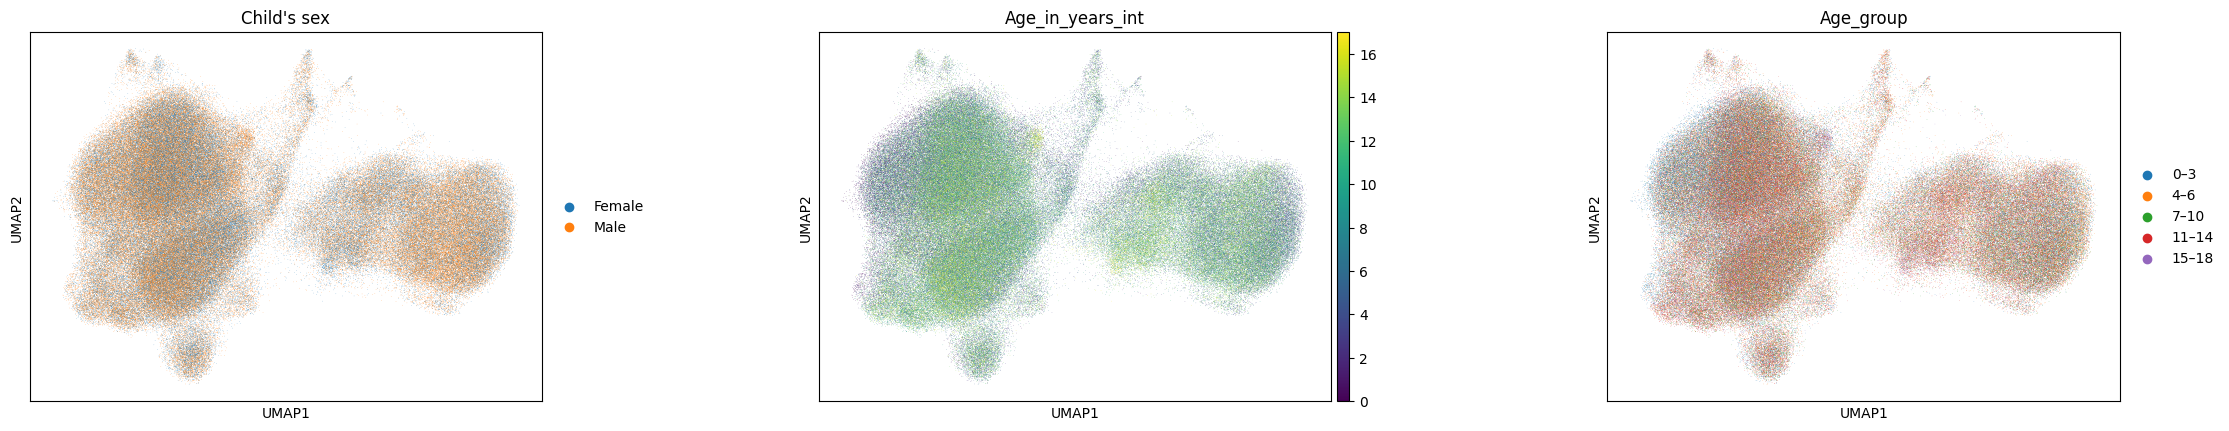

In [24]:
sc.pl.umap(adata_scvi_cd8, color=["Child's sex", "Age_in_years_int", "Age_group"], wspace=0.4)

#### convert to sce object

In [5]:
import anndata2ri
import rpy2.robjects as robjects
from rpy2.robjects.conversion import localconverter

with localconverter(anndata2ri.converter):
        sce = anndata2ri.py2rpy(adata_scvi_cd8)

# Save the sce object in .rds file
robjects.globalenv["sce"] = sce
robjects.r("saveRDS(sce, file='{}')".format("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd8_combined_annot_with_age_scvi.sce.rds"))

ImportError: cannot import name 'conversion' from 'rpy2.robjects' (unknown location)

#### run scvi for nk

In [25]:
adata_scvi_nk =sc.read_h5ad("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_nk_combined_annot_with_age.h5ad")

adata_scvi_nk.obs['pica_cell_type_complete_01_gdT_corrected'].unique()
adata_scvi_nk.obs['pica_cell_type_complete_01_gdT_corrected'].value_counts()

pica_cell_type_complete_01_gdT_corrected
CD56_dim CD16+ NK           171221
ILC1                         16331
CD56_dim CD16+ KLRC2+ NK     15081
iILC2                         2400
nILC2                         1554
CD56_bright CD16- NK           871
Name: count, dtype: int64

In [26]:
adata_scvi_nk.layers["counts"] = adata_scvi_nk.X.copy()

In [27]:
scvi.model.SCVI.setup_anndata(
    adata_scvi_nk,
    layer="counts",    
    batch_key="pica_id" 
)

In [28]:
scvi.model.SCVI.setup_anndata(adata_scvi_nk, layer="counts", batch_key="pica_id")

In [29]:
model_nk = scvi.model.SCVI(adata_scvi_nk, n_layers=2, n_latent=30, gene_likelihood="nb")

In [30]:
model_nk.train()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/39 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=39` reached.


In [31]:
adata_scvi_nk.obsm["X_scVI"] = model_nk.get_latent_representation()

#  latent representation 
sc.pp.neighbors(adata_scvi_nk, use_rep="X_scVI")
sc.tl.umap(adata_scvi_nk)

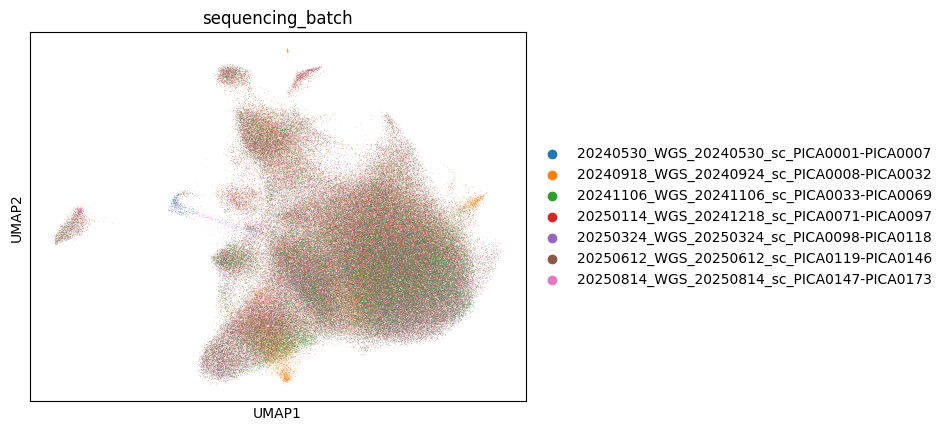

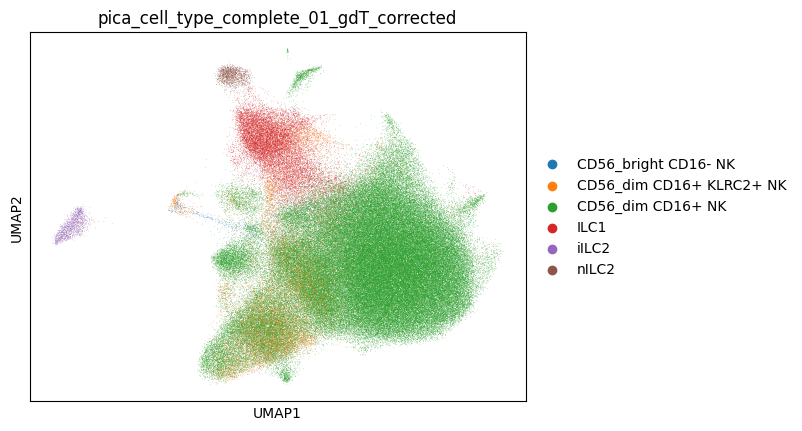

In [32]:

sc.pl.umap(adata_scvi_nk, color="sequencing_batch")
sc.pl.umap(adata_scvi_nk, color="pica_cell_type_complete_01_gdT_corrected")

In [33]:
print(adata_scvi_nk)

AnnData object with n_obs × n_vars = 207458 × 38606
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 
'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 
'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 
'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 
'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 
'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 
'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 
'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 
'status_manual_01_pica', 'Record ID', 'Sex', 'Age (years)', 'Age', 'Event Name', 'Was baseline blood sample 
collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of 
collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood 
collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown
any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating
medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune 
disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) 
(choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies 
and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or 
your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, 
type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family 
member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) 
What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian 
Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's
ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your 
child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) 
What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern
and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is
your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)",
"9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? 
(choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What
is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please 
specify:)", 'Specify ethnicity', 'Age_in_years_int', 'Age_group', '_scvi_batch', '_scvi_labels'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
    uns: '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'umap', 'sequencing_batch_colors', 
'pica_cell_type_complete_01_gdT_corrected_colors'
    obsm: 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [34]:
adata_scvi_nk.write_h5ad("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_nk_combined_annot_with_age_scvi.h5ad", compression="gzip")

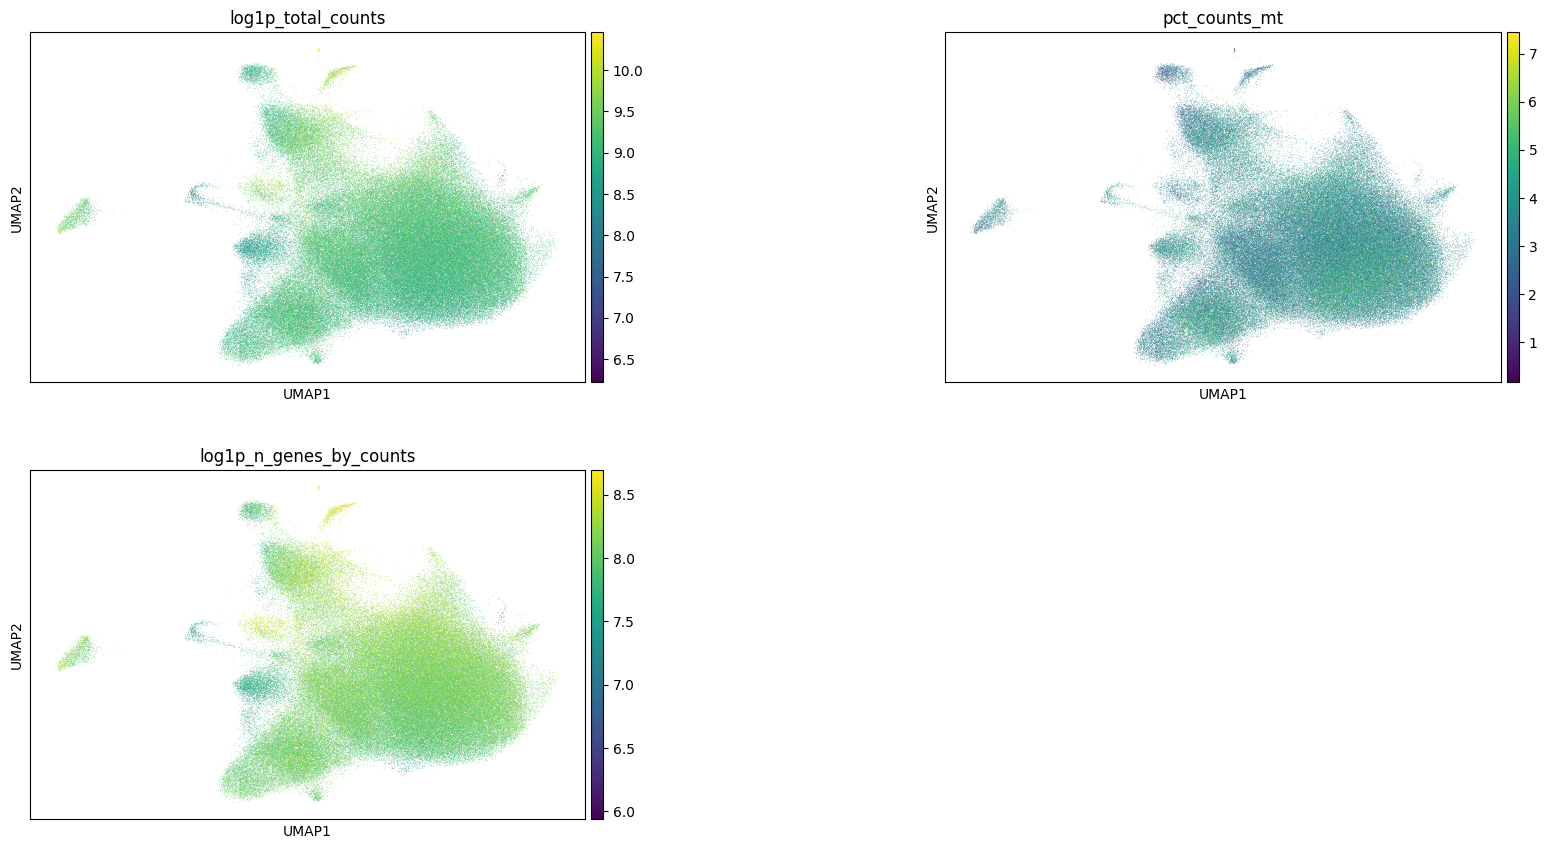

In [35]:
sc.pl.umap(
    adata_scvi_nk,
    color=["log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"],
    wspace=0.5,
    ncols=2
)

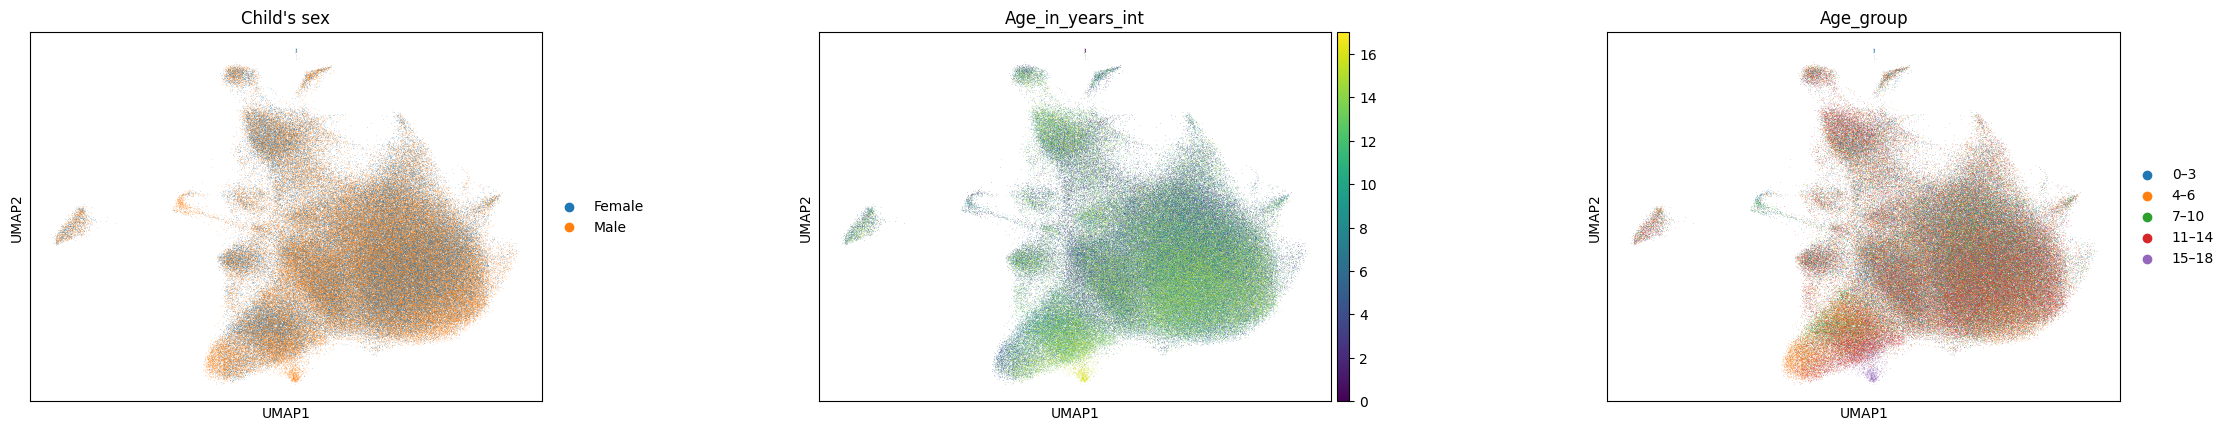

In [36]:
sc.pl.umap(adata_scvi_nk, color=["Child's sex", "Age_in_years_int", "Age_group"], wspace=0.4)

#### convert to sce object

In [ ]:
import anndata2ri
import rpy2.robjects as robjects
from rpy2.robjects.conversion import localconverter

with localconverter(robjects.default_converter + anndata2ri.converter):
    sce = robjects.conversion.py2rpy(adata_scvi_nk)

# Save the sce object in .rds file
robjects.globalenv["sce"] = sce
robjects.r("saveRDS(sce, file='{}')".format("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_nk_combined_annot_with_age_scvi.sce.rds"))